<a href="https://colab.research.google.com/github/misge8-del/heart-disease-prediction-ml/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Heart Disease Prediction using Machine Learning

## End-to-End Machine Learning Project

**Author:** Misgina Gebregergs

**Institution:** Addis Ababa University

---

## 📖 Project Overview

Heart disease is one of the leading causes of death worldwide. Early prediction of cardiovascular disease can help healthcare professionals identify high-risk patients, improve clinical decision-making, and provide timely treatment.

In this project, we build an end-to-end machine learning pipeline to predict the presence of heart disease using patient clinical data. The workflow includes data exploration, preprocessing, feature engineering, model development, and performance evaluation.

---

## 🎯 Project Objectives

- Understand the dataset and its characteristics.
- Perform exploratory data analysis (EDA).
- Clean and preprocess the data.
- Engineer meaningful features.
- Train a machine learning classification model.
- Evaluate model performance using multiple metrics.
- Interpret the results and discuss future improvements.

---

## 🛠️ Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

---

## 📌 Machine Learning Workflow

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Conclusion

In [544]:
# Heart Disease Prediction using Machine Learning

import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification model
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# 📂 Loading the Dataset

The first step in any machine learning project is loading the dataset into a Pandas DataFrame. This allows us to inspect the data, understand its structure, and prepare it for analysis and modeling.

In [545]:
# Upload dataset
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [546]:
# Load the dataset from csv file
df = pd.read_csv('/content/Heart_Disease_Prediction (2).csv')

# Display the first five rows
df.head()

,ID,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,1.0,70,Male,4,130,322,0,2,109,0,2.4,2,3,3,1
1,2.0,67,Female,3,115,564,0,2,160,0,1.6,2,0,7,0
2,3.0,57,Male,2,124,261,0,0,141,0,0.3,1,0,7,1
3,NaN,64,Male,4,128,263,0,0,105,1,0.2,2,1,7,0
4,NaN,74,Female,2,120,269,0,2,121,1,0.2,1,1,3,0


In [547]:
# Display basic information about the dataset
df.info()
# Display basic Statical summary about the dataset
df.describe()
# Display basic missing value about the dataset
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       3 non-null      float64
 1   Age                      270 non-null    int64  
 2   Sex                      270 non-null    object 
 3   Chest pain type          270 non-null    int64  
 4   BP                       270 non-null    int64  
 5   Cholesterol              270 non-null    int64  
 6   FBS over 120             270 non-null    int64  
 7   EKG results              270 non-null    int64  
 8   Max HR                   270 non-null    int64  
 9   Exercise angina          270 non-null    int64  
 10  ST depression            270 non-null    float64
 11  Slope of ST              270 non-null    int64  
 12  Number of vessels fluro  270 non-null    int64  
 13  Thallium                 270 non-null    int64  
 14  Heart Disease            2

,0
ID,267
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


# 🔍 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step in every machine learning project. It helps us understand the dataset, identify potential data quality issues, and gain insights before building predictive models.

During this stage, we examine the dataset's structure, inspect feature types, identify missing values and duplicate records, and summarize the statistical properties of the data.

In [548]:
# Display dataset dimensions
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 270
Number of Columns : 15


### Dataset Dimensions

The dataset contains 270 patient records and 15 features. Each row represents one patient, while each column contains clinical or demographic information that may contribute to predicting heart disease.

In [549]:
# Display all column names
df.columns

Index(['ID', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [550]:
# Display data types
df.dtypes

,0
ID,float64
Age,int64
Sex,object
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


In [551]:
# Display missing values
missing_values = df.isnull().sum()

missing_values

,0
ID,267
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


### Missing Values Analysis

The dataset contains missing values only in the **ID** column, where 267 out of 270 records are missing.

Since the ID column is not useful for prediction and contains a large number of missing values, it will be removed during the data preprocessing stage.

In [552]:
# Check for duplicate records
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [553]:

#Display information of numerical features
df.info()
# Statistical summary of numerical features
df.describe().T
# Display basic missing of numerical features
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       3 non-null      float64
 1   Age                      270 non-null    int64  
 2   Sex                      270 non-null    object 
 3   Chest pain type          270 non-null    int64  
 4   BP                       270 non-null    int64  
 5   Cholesterol              270 non-null    int64  
 6   FBS over 120             270 non-null    int64  
 7   EKG results              270 non-null    int64  
 8   Max HR                   270 non-null    int64  
 9   Exercise angina          270 non-null    int64  
 10  ST depression            270 non-null    float64
 11  Slope of ST              270 non-null    int64  
 12  Number of vessels fluro  270 non-null    int64  
 13  Thallium                 270 non-null    int64  
 14  Heart Disease            2

,0
ID,267
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


# 🔍 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step in any machine learning project. It helps us understand the dataset's structure, identify potential data quality issues, detect missing values, analyze feature distributions, and uncover relationships between variables before building predictive models.

The objective of this analysis is to gain meaningful insights into the heart disease dataset and prepare it for preprocessing and model development.

In [554]:
# Display dataset dimensions

rows, columns = df.shape

print("=" * 40)
print("DATASET OVERVIEW")
print("=" * 40)
print(f"Number of Patients : {rows}")
print(f"Number of Features : {columns}")

DATASET OVERVIEW
Number of Patients : 270
Number of Features : 15


### Observation

The dataset contains **270 patient records** and **15 variables**, including one target variable (`Heart Disease`) that indicates whether a patient has heart disease.

In [555]:
df.dtypes

,0
ID,float64
Age,int64
Sex,object
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Observation

Most variables are numerical, making them suitable for machine learning algorithms. The `Sex` feature is categorical and will require encoding before model training.

In [556]:
missing = df.isnull().sum()

missing

,0
ID,267
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


### Observation

Only the **ID** column contains missing values (267 missing entries). Since this column does not provide meaningful predictive information and contains a large number of missing values, it will be removed during the preprocessing stage.

All remaining features are complete and require no missing value treatment.

In [557]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


### Observation

Duplicate records can introduce bias into machine learning models. If duplicate observations are found, they will be removed during data preprocessing.

In [558]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,3.0,2.000000,1.000000,1.0,1.5,2.0,2.5,3.0
Age,270.0,54.433333,9.109067,29.0,48.0,55.0,61.0,77.0
Chest pain type,270.0,3.174074,0.950090,1.0,3.0,3.0,4.0,4.0
BP,270.0,131.344444,17.861608,94.0,120.0,130.0,140.0,200.0
Cholesterol,270.0,249.659259,51.686237,126.0,213.0,245.0,280.0,564.0
FBS over 120,270.0,0.148148,0.355906,0.0,0.0,0.0,0.0,1.0
EKG results,270.0,1.022222,0.997891,0.0,0.0,2.0,2.0,2.0
Max HR,270.0,149.677778,23.165717,71.0,133.0,153.5,166.0,202.0
Exercise angina,270.0,0.329630,0.470952,0.0,0.0,0.0,1.0,1.0
ST depression,270.0,1.050000,1.145210,0.0,0.0,0.8,1.6,6.2


### Observation

The statistical summary provides important insights into the numerical features.

- The average patient age is approximately **54 years**.
- The average cholesterol level is around **250 mg/dL**.
- The average resting blood pressure is approximately **131 mmHg**.
- The target variable (`Heart Disease`) is binary, where:
  - **0** indicates no heart disease.
  - **1** indicates heart disease.

In [559]:
print(df.columns.tolist())

['ID', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


# Data Preparation

Before beginning the analysis, we standardize the column names to improve readability and make the code easier to write and maintain. This is a common practice in data science projects.

In [560]:
# Rename columns for consistency and easier coding
df.columns = [
    "ID",
    "Age",
    "Sex",
    "Chest_Pain_Type",
    "Blood_Pressure",
    "Cholesterol",
    "FBS_Over_120",
    "EKG_Results",
    "Max_Heart_Rate",
    "Exercise_Angina",
    "ST_Depression",
    "ST_Slope",
    "Num_Major_Vessels",
    "Thallium",
    "Heart_Disease"
]

# Display updated column names
print(df.columns.tolist())

['ID', 'Age', 'Sex', 'Chest_Pain_Type', 'Blood_Pressure', 'Cholesterol', 'FBS_Over_120', 'EKG_Results', 'Max_Heart_Rate', 'Exercise_Angina', 'ST_Depression', 'ST_Slope', 'Num_Major_Vessels', 'Thallium', 'Heart_Disease']


# Data Visualization

Visualizing the data helps us understand the distribution of features, identify patterns, and explore relationships that may influence the prediction of heart disease.

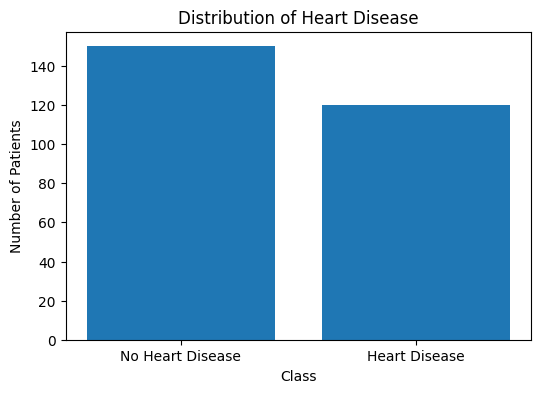

In [561]:
# Distribution of the target variable

heart_counts = df["Heart_Disease"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["No Heart Disease", "Heart Disease"], heart_counts.values)

plt.title("Distribution of Heart Disease")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.show()

### Observation

The chart shows the distribution of patients with and without heart disease.

Understanding the balance between the two classes is important because highly imbalanced datasets can affect model performance and may require additional preprocessing techniques.

## Age Distribution

Age is one of the most important risk factors associated with cardiovascular disease. Understanding the age distribution of patients helps identify the age groups most represented in the dataset.

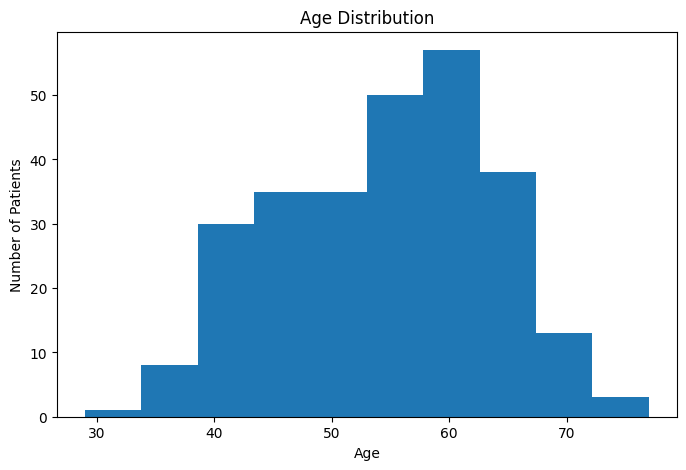

In [562]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

### Observation

Most patients in the dataset are between **45 and 65 years old**. This age range is commonly associated with a higher risk of cardiovascular disease, making age an important predictive feature.

## Gender Distribution

Gender is an important demographic feature that may influence the occurrence of heart disease. Analyzing the distribution of male and female patients helps us better understand the composition of the dataset.

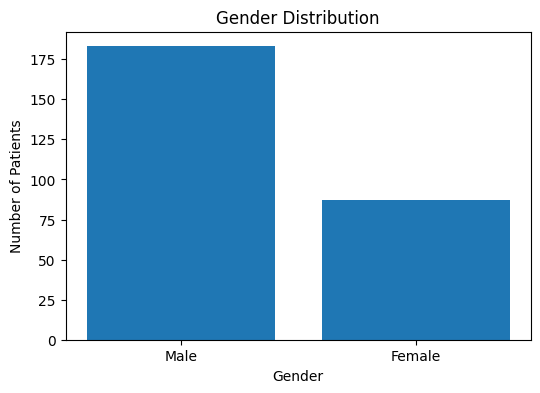

In [563]:
gender_counts = df["Sex"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(gender_counts.index, gender_counts.values)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

### Observation

The dataset contains a significantly higher number of male patients than female patients. This imbalance should be considered when interpreting the results, as the model may learn more patterns from male patients.

## Cholesterol Distribution

Cholesterol is one of the major clinical indicators associated with cardiovascular health. Visualizing its distribution helps identify common cholesterol levels and detect any unusually high values.

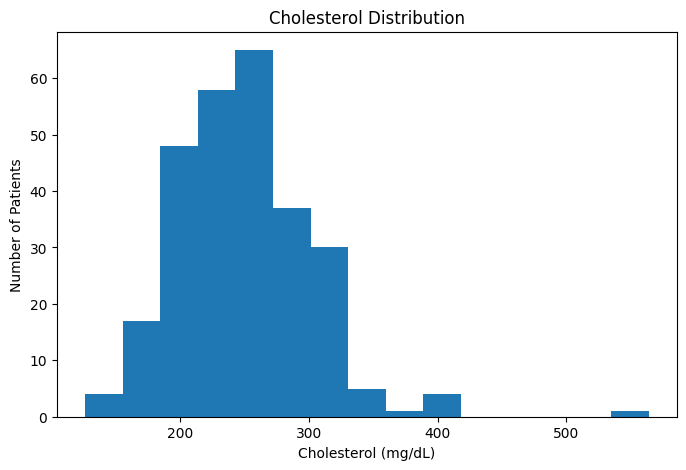

In [564]:
plt.figure(figsize=(8,5))

plt.hist(df["Cholesterol"], bins=15)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Number of Patients")

plt.show()

### Observation

Most patients have cholesterol levels between **200 and 300 mg/dL**. A small number of patients have exceptionally high cholesterol values, which may be potential outliers and could influence the machine learning model.

## Blood Pressure Distribution

Resting blood pressure is an important cardiovascular measurement. Examining its distribution helps identify the typical blood pressure range of patients included in the dataset.

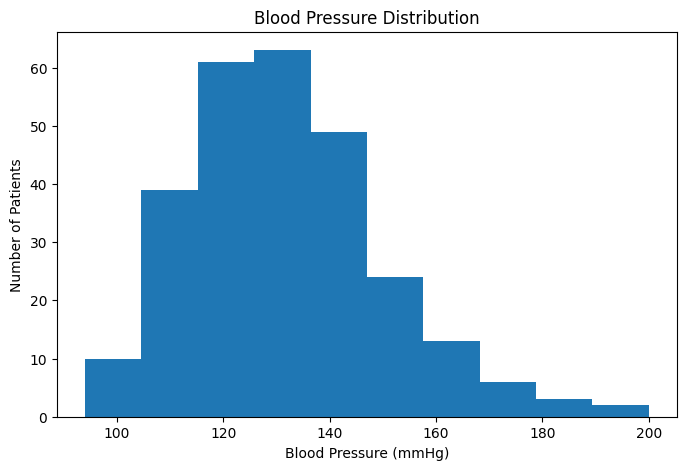

In [565]:
plt.figure(figsize=(8,5))

plt.hist(df["Blood_Pressure"], bins=10)

plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure (mmHg)")
plt.ylabel("Number of Patients")

plt.show()

### Observation

### Observation

The majority of patients have resting blood pressure values between **120 and 140 mmHg**. A few patients exhibit unusually high blood pressure values, which may indicate increased cardiovascular risk and could represent potential outliers.

# Correlation Analysis

Correlation analysis helps us understand the relationships between numerical features in the dataset. It measures how strongly variables are related to each other and can identify which features may have the greatest influence on heart disease prediction.

Values close to **1** indicate a strong positive relationship, values close to **-1** indicate a strong negative relationship, and values near **0** indicate little or no relationship.

In [566]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display the correlation matrix
correlation_matrix

,ID,Age,Chest_Pain_Type,Blood_Pressure,Cholesterol,FBS_Over_120,EKG_Results,Max_Heart_Rate,Exercise_Angina,ST_Depression,ST_Slope,Num_Major_Vessels,Thallium,Heart_Disease
ID,1.000000,-0.954919,-1.000000,-0.397360,-0.190319,NaN,-0.866025,0.620765,NaN,-0.990684,-0.866025,-0.866025,0.866025,0.000000
Age,-0.954919,1.000000,0.096920,0.273053,0.220056,0.123458,0.128171,-0.402215,0.098297,0.194234,0.159774,0.356081,0.106100,0.212322
Chest_Pain_Type,-1.000000,0.096920,1.000000,-0.043196,0.090465,-0.098537,0.074325,-0.317682,0.353160,0.167244,0.136900,0.225890,0.262659,0.417436
Blood_Pressure,-0.397360,0.273053,-0.043196,1.000000,0.173019,0.155681,0.116157,-0.039136,0.082793,0.222800,0.142472,0.085697,0.132045,0.155383
Cholesterol,-0.190319,0.220056,0.090465,0.173019,1.000000,0.025186,0.167652,-0.018739,0.078243,0.027709,-0.005755,0.126541,0.028836,0.118021
FBS_Over_120,NaN,0.123458,-0.098537,0.155681,0.025186,1.000000,0.053499,0.022494,-0.004107,-0.025538,0.044076,0.123774,0.049237,-0.016319
EKG_Results,-0.866025,0.128171,0.074325,0.116157,0.167652,0.053499,1.000000,-0.074628,0.095098,0.120034,0.160614,0.114368,0.007337,0.182091
Max_Heart_Rate,0.620765,-0.402215,-0.317682,-0.039136,-0.018739,0.022494,-0.074628,1.000000,-0.380719,-0.349045,-0.386847,-0.265333,-0.253397,-0.418514
Exercise_Angina,NaN,0.098297,0.353160,0.082793,0.078243,-0.004107,0.095098,-0.380719,1.000000,0.274672,0.255908,0.153347,0.321449,0.419303
ST_Depression,-0.990684,0.194234,0.167244,0.222800,0.027709,-0.025538,0.120034,-0.349045,0.274672,1.000000,0.609712,0.255005,0.324333,0.417967


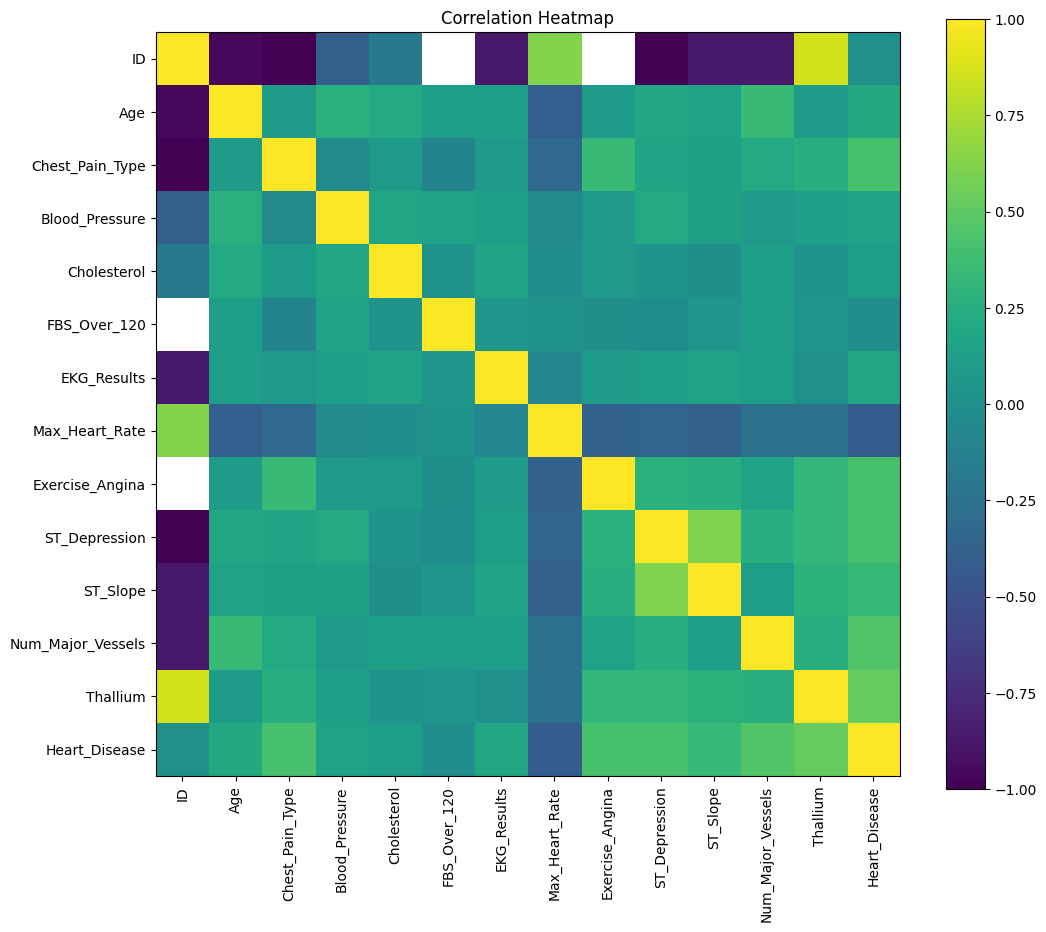

In [567]:
# Display the correlation matrix as a heatmap

plt.figure(figsize=(12,10))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap provides a visual summary of the relationships between numerical features.

Features with stronger positive or negative correlations may be more useful for predicting heart disease. Features with correlations close to zero have little linear relationship with other variables.

The heatmap also helps identify highly correlated features that may contain redundant information.

## Correlation with the Target Variable

To better understand which clinical measurements are most strongly associated with heart disease, we calculate the correlation of every feature with the target variable.

In [568]:
target_corr = correlation_matrix["Heart_Disease"].drop("Heart_Disease")

target_corr = target_corr.reindex(
    target_corr.abs().sort_values(ascending=False).index
)

target_corr

,Heart_Disease
Thallium,0.525020
Num_Major_Vessels,0.455336
Exercise_Angina,0.419303
Max_Heart_Rate,-0.418514
ST_Depression,0.417967
Chest_Pain_Type,0.417436
ST_Slope,0.337616
Age,0.212322
EKG_Results,0.182091
Blood_Pressure,0.155383


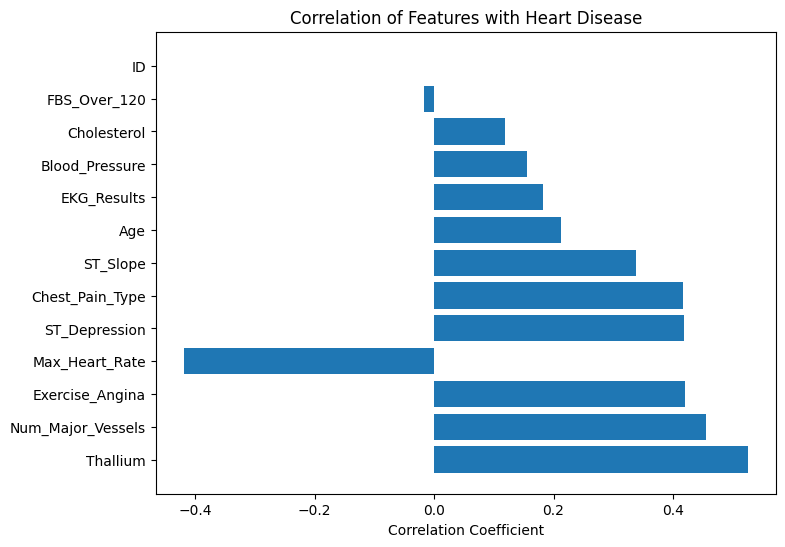

In [569]:
plt.figure(figsize=(8,6))

plt.barh(target_corr.index, target_corr.values)

plt.title("Correlation of Features with Heart Disease")
plt.xlabel("Correlation Coefficient")

plt.show()

### Observation

The correlation analysis reveals which clinical features have the strongest relationship with heart disease.

Features such as **Thallium**, **Number of Major Vessels**, **Exercise Angina**, and **ST Depression** show relatively strong positive correlations with the target variable, indicating that they may be important predictors.

Conversely, **Maximum Heart Rate** exhibits a negative correlation, suggesting that higher maximum heart rates are generally associated with a lower likelihood of heart disease in this dataset.

These findings provide valuable insight into the factors that may contribute most to the predictive performance of the machine learning model.

# Data Preprocessing

Before training a machine learning model, the dataset must be cleaned and transformed into a suitable format. This preprocessing stage includes removing unnecessary columns, handling missing values, encoding categorical variables, scaling numerical features, and splitting the dataset into training and testing sets.

## Removing the ID Column

The **ID** column is a unique identifier for each patient and does not contain meaningful clinical information for predicting heart disease.

Additionally, this column contains **267 missing values**, making it unsuitable for analysis. Therefore, it will be removed from the dataset.

In [570]:
# Check if ID exists before removing it
if "ID" in df.columns:
    df.drop(columns=["ID"], inplace=True)

# Display current columns
print(df.columns.tolist())

['Age', 'Sex', 'Chest_Pain_Type', 'Blood_Pressure', 'Cholesterol', 'FBS_Over_120', 'EKG_Results', 'Max_Heart_Rate', 'Exercise_Angina', 'ST_Depression', 'ST_Slope', 'Num_Major_Vessels', 'Thallium', 'Heart_Disease']


In [571]:
print(df.columns.tolist())

['Age', 'Sex', 'Chest_Pain_Type', 'Blood_Pressure', 'Cholesterol', 'FBS_Over_120', 'EKG_Results', 'Max_Heart_Rate', 'Exercise_Angina', 'ST_Depression', 'ST_Slope', 'Num_Major_Vessels', 'Thallium', 'Heart_Disease']


### Observation

The **ID** column has been successfully removed. The remaining features contain relevant clinical information that will be used for model training.

## Checking for Missing Values

Missing values can negatively affect the performance of machine learning models. After removing the **ID** column, we verify that no missing values remain in the dataset.

In [572]:
# Check for missing values
print(df.isnull().sum())

Age                  0
Sex                  0
Chest_Pain_Type      0
Blood_Pressure       0
Cholesterol          0
FBS_Over_120         0
EKG_Results          0
Max_Heart_Rate       0
Exercise_Angina      0
ST_Depression        0
ST_Slope             0
Num_Major_Vessels    0
Thallium             0
Heart_Disease        0
dtype: int64


### Observation

The dataset contains no missing values after removing the **ID** column. Therefore, no additional missing value treatment is required.

## Checking for Duplicate Records

Duplicate records can introduce bias into a machine learning model. Therefore, we check whether any duplicate observations exist in the dataset.

In [573]:
# Count duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Observation

No duplicate records were found in the dataset. Therefore, no duplicate removal was necessary.

## Encoding Categorical Variables

Machine learning algorithms require numerical input. The `Sex` feature is currently stored as text values (`Male` and `Female`), so it must be converted into numerical values before training the model.

We will use **Label Encoding**, where:

- Male → 1
- Female → 0

In [574]:
# Encode the Sex column
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Sex"] = label_encoder.fit_transform(df["Sex"])

# Display the first five rows
df.head()

,Age,Sex,Chest_Pain_Type,Blood_Pressure,Cholesterol,FBS_Over_120,EKG_Results,Max_Heart_Rate,Exercise_Angina,ST_Depression,ST_Slope,Num_Major_Vessels,Thallium,Heart_Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [575]:
# Verify the encoded values
print(df["Sex"].unique())

[1 0]


### Observation

The `Sex` feature has been successfully encoded into numerical values. This transformation enables machine learning algorithms to process the feature while preserving its categorical information.

## Feature Engineering

Feature engineering involves creating new variables from existing data to improve model performance and provide additional information to the machine learning algorithm.

In this project, we create an **Age Group** feature by categorizing patients into different age ranges.

In [576]:
# Create Age_Group feature
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 40, 55, 70, 100],
    labels=["Young", "Middle-aged", "Senior", "Elderly"]
)

df.head()

,Age,Sex,Chest_Pain_Type,Blood_Pressure,Cholesterol,FBS_Over_120,EKG_Results,Max_Heart_Rate,Exercise_Angina,ST_Depression,ST_Slope,Num_Major_Vessels,Thallium,Heart_Disease,Age_Group
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1,Senior
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0,Senior
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1,Senior
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0,Senior
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0,Elderly


In [577]:
# Display Age_Group distribution
df["Age_Group"].value_counts()

,count
Age_Group,
Senior,126
Middle-aged,123
Young,15
Elderly,6


### Observation

The newly created **Age_Group** feature categorizes patients into meaningful age ranges. This feature may help the model capture age-related patterns that are less obvious when using the raw age values alone.

## Encoding the Age_Group Feature

The `Age_Group` feature contains categorical values, which must be converted into numerical values before training the machine learning model.

We use **Label Encoding** to transform each age group into a unique integer while preserving the category information.

In [578]:
# Encode the Age_Group feature
from sklearn.preprocessing import LabelEncoder

age_group_encoder = LabelEncoder()

df["Age_Group"] = age_group_encoder.fit_transform(df["Age_Group"])

# Display the first five rows
df.head()

,Age,Sex,Chest_Pain_Type,Blood_Pressure,Cholesterol,FBS_Over_120,EKG_Results,Max_Heart_Rate,Exercise_Angina,ST_Depression,ST_Slope,Num_Major_Vessels,Thallium,Heart_Disease,Age_Group
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0,2
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0,2
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0,0


In [579]:
# Convert Age_Group to integer
df["Age_Group"] = df["Age_Group"].astype(int)

print(df["Age_Group"].dtype)
print(df["Age_Group"].head())

int64
0    2
1    2
2    2
3    2
4    0
Name: Age_Group, dtype: int64


In [580]:
# Check the encoded values
print(df["Age_Group"].unique())

[2 0 1 3]


### Observation

The `Age_Group` feature has been successfully converted into numerical values, making it suitable for machine learning algorithms.

## Feature Scaling

Feature scaling standardizes numerical variables so that they have a similar range. This helps many machine learning algorithms train more efficiently and prevents features with larger values from dominating the model.

In [581]:
# Separate features and target
X = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (270, 14)
Target shape: (270,)


In [582]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (216, 14)
Testing set: (54, 14)


In [583]:
print(X_train.dtypes)

Age                    int64
Sex                    int64
Chest_Pain_Type        int64
Blood_Pressure         int64
Cholesterol            int64
FBS_Over_120           int64
EKG_Results            int64
Max_Heart_Rate         int64
Exercise_Angina        int64
ST_Depression        float64
ST_Slope               int64
Num_Major_Vessels      int64
Thallium               int64
Age_Group              int64
dtype: object


In [584]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [585]:
print(df.isnull().sum())

Age                  0
Sex                  0
Chest_Pain_Type      0
Blood_Pressure       0
Cholesterol          0
FBS_Over_120         0
EKG_Results          0
Max_Heart_Rate       0
Exercise_Angina      0
ST_Depression        0
ST_Slope             0
Num_Major_Vessels    0
Thallium             0
Heart_Disease        0
Age_Group            0
dtype: int64


### Observation

The dataset has been successfully divided into training and testing sets. Feature scaling was applied using `StandardScaler`, ensuring that all numerical features contribute equally during model training.

# Model Development

Logistic Regression is selected because this is a binary classification problem (Heart Disease: Yes or No). It is efficient, interpretable, and performs well as a baseline model for medical prediction tasks.

In [586]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


## Making Predictions

Once the model has been trained, it can be used to predict heart disease for patients in the testing dataset.

In [587]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Display the first 10 predictions
print(y_pred[:10])

[1 0 0 0 0 1 1 0 0 0]


# Model Evaluation

To evaluate the model, we calculate several classification metrics including Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix. These metrics provide a comprehensive assessment of the model's predictive performance.

In [588]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8518518518518519
Precision: 0.8421052631578947
Recall   : 0.7619047619047619
F1 Score : 0.8


## Confusion Matrix

A confusion matrix provides a detailed view of the model's predictions by comparing predicted labels with the actual labels.

In [589]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[30  3]
 [ 5 16]]


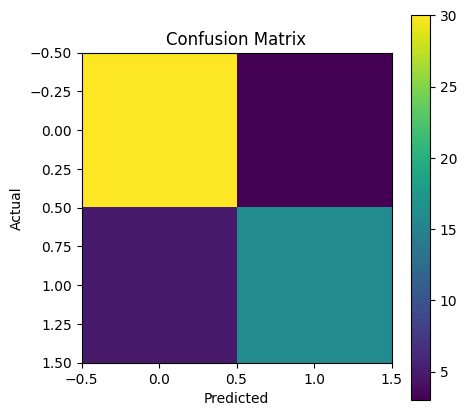

In [590]:
plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [591]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88        33
           1       0.84      0.76      0.80        21

    accuracy                           0.85        54
   macro avg       0.85      0.84      0.84        54
weighted avg       0.85      0.85      0.85        54



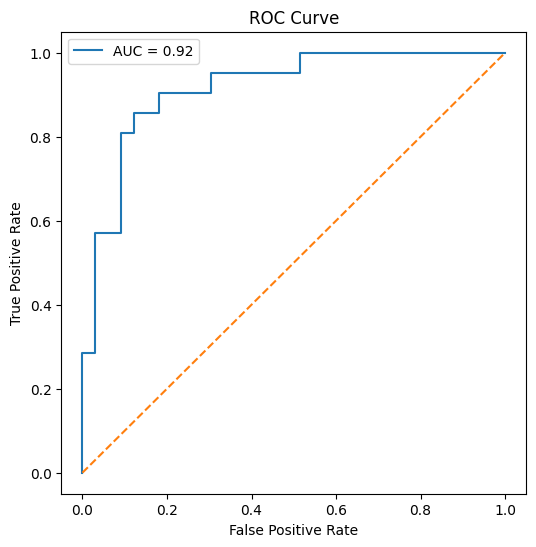

AUC Score: 0.9163059163059163


In [592]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score:", roc_auc)

# Conclusion

In this project demonstrates, an end-to-end machine learning workflow was implemented to predict heart disease using clinical patient data.

The project included:

- Data loading and exploration
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Feature scaling
- Model development using Logistic Regression
- Model evaluation using multiple performance metrics

The results demonstrate that Logistic Regression provides a strong baseline model for heart disease prediction. Future work could include experimenting with more advanced algorithms such as Random Forest, Support Vector Machines (SVM), or XGBoost to potentially improve predictive performance.